<a href="https://colab.research.google.com/github/MishaE-e/1/blob/main/%D0%95%D0%BB%D1%8C%D1%88%D0%B8%D0%BD_%D0%9C%D0%B8%D1%85%D0%B0%D0%B8%D0%BB_%D0%A0%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D0%BE%D0%BD%D0%BD%D1%8B%D0%B8%CC%86_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D0%9D%D0%BE%D0%B2%D0%BE%D1%80%D0%BE%D1%81%D1%81%D0%B8%D0%B9%D1%81%D0%BA(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ельшин Михаил Алексеевич

группы ФМ/О РФЗ-1-2022 НБ

Лабораторная работа: Регрессионный анализ

Задача: есть набор данных, в котором объекты описаны признаками X, и каждому объекту в соответствие поставлен целевой признак Y. Необходимо построить такой алгоритм, который позволит по переданному, ранее неизвестному, описанию объекта Xi сформировать оценку соответствующего целевого признака Yi.

В данной лабораторной работе решается задача анализа рынка недвижимости и построения моделей прогнозирования цен на квартиры.

В качестве примера используется набор данныхо недвижимости в городах России. Данные можно посмотреть по ссылке https://www.kaggle.com/datasets/mrdaniilak/russia-real-estate-20182021. Из всего набора данных используются данные по Новороссийску.

Набор данных описывается следующими колонками

* date - дата публикации объявления;
* time - время публикации объявления;
* geo_lat - широта объекта недвижимости в градусах;
* geo_lon - долгота;
* region - код региона России (но с техническими правками).
* building_type - технология стройки: 0 - другая, 1 - панельный дом, 2 - монолитный каркас, 3 - кирпичный дом, 4 - блочный (газобетон, ПГП), 5 - деревянный;
* object_type - тип объекта: 1 - вторичный; 2 - первичная продажа от застройщика;
* level - этаж;
* levels - общее количество этажей в доме;
* rooms - количество жилых комнат: "-1" означает студию.
* area - общая площадь, кв.м.
* kitchen_area - площадь кухни, кв.м.
* price - цена, руб.

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive

In [ ]:
df = pd.read_csv("all_v2.csv",parse_dates=['date'])
df

,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
0,6050000,2018-02-19,20:00:21,59.805808,30.376141,2661,1,8,10,3,82.6,10.8,1
1,8650000,2018-02-27,12:04:54,55.683807,37.297405,81,3,5,24,2,69.1,12.0,1
2,4000000,2018-02-28,15:44:00,56.295250,44.061637,2871,1,5,9,3,66.0,10.0,1
3,1850000,2018-03-01,11:24:52,44.996132,39.074783,2843,4,12,16,2,38.0,5.0,11
4,5450000,2018-03-01,17:42:43,55.918767,37.984642,81,3,13,14,2,60.0,10.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5477001,19739760,2021-05-01,20:13:58,55.804736,37.750898,3,1,8,17,4,93.2,13.8,11
5477002,12503160,2021-05-01,20:14:01,55.841415,37.489624,3,2,17,32,2,45.9,6.6,11
5477003,8800000,2021-05-01,20:14:04,56.283909,44.075408,2871,2,4,17,3,86.5,11.8,1
5477004,11831910,2021-05-01,20:14:12,55.804736,37.750898,3,1,8,33,2,52.1,18.9,11


Фильтор по координатам города (Новороссийск)

Значения координат границ города взяты из карт https://yandex.ru/maps/geo/novorossiysk/53166106/?ll=37.750096%2C44.723057&z=12

In [ ]:
df_nov = df[
    (df["geo_lat"] >= 44.6) &
    (df["geo_lat"] <= 44.8) &
    (df["geo_lon"] >= 37.6) &
    (df["geo_lon"] <= 37.9)
]
df_nov

,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
242,2800000,2018-09-08,00:15:18,44.672702,37.787363,2843,2,5,16,2,60.0,11.8,1
248,2662000,2018-09-08,00:16:15,44.710944,37.777307,2843,2,4,12,1,48.4,15.1,1
251,6300000,2018-09-08,00:18:00,44.681239,37.786473,2843,2,5,6,3,136.0,10.0,1
293,2900000,2018-09-08,00:50:26,44.672702,37.787363,2843,2,4,16,2,60.3,10.7,11
304,4800000,2018-09-08,00:54:45,44.675917,37.789169,2843,2,13,14,3,107.0,13.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5476001,5220000,2021-05-01,18:16:42,44.723503,37.768614,2843,2,7,20,1,46.0,4.4,11
5476153,4150000,2021-05-01,18:40:43,44.762534,37.713772,2843,1,5,5,3,69.0,12.0,1
5476398,1650000,2021-05-01,18:55:44,44.736623,37.731739,2843,1,5,5,1,13.0,4.0,1
5476894,6500000,2021-05-01,19:51:42,44.661731,37.761653,2843,2,3,5,2,65.0,12.0,1


Фильтор по дате (2018 год)

In [ ]:
from datetime import datetime
date2017 = datetime(2018, 1, 1)
date2019 = datetime(2018, 12, 31)

In [ ]:
df_nov = df_nov[(df_nov["date"]>=date2017) & (df_nov["date"]<=date2019)]
df_nov

,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
242,2800000,2018-09-08,00:15:18,44.672702,37.787363,2843,2,5,16,2,60.0,11.8,1
248,2662000,2018-09-08,00:16:15,44.710944,37.777307,2843,2,4,12,1,48.4,15.1,1
251,6300000,2018-09-08,00:18:00,44.681239,37.786473,2843,2,5,6,3,136.0,10.0,1
293,2900000,2018-09-08,00:50:26,44.672702,37.787363,2843,2,4,16,2,60.3,10.7,11
304,4800000,2018-09-08,00:54:45,44.675917,37.789169,2843,2,13,14,3,107.0,13.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
855278,1480000,2018-12-31,09:36:42,44.697248,37.776876,2843,1,1,9,1,20.8,6.0,1
855693,2250000,2018-12-31,10:29:41,44.660489,37.760306,2843,2,3,6,1,43.0,10.0,1
855715,2700000,2018-12-31,10:31:31,44.739613,37.723699,2843,1,2,16,1,40.0,10.0,1
856095,1450000,2018-12-31,13:03:07,44.738652,37.713737,2843,2,2,3,1,27.0,7.0,1


Считаем расстояние до ценнтра города

In [ ]:
from math import sqrt
latc = 44.723771
lonc = 37.768808
from geopy import distance
def distance_2(row):
  return distance.distance((latc,lonc),(row["geo_lat"],row["geo_lon"])).km


In [ ]:
df_nov_distance=df_nov.copy()
df_nov_distance["distance"]=df_nov.apply(lambda row: distance_2(row),axis=1)
df_nov_distance

,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type,distance
242,2800000,2018-09-08,00:15:18,44.672702,37.787363,2843,2,5,16,2,60.0,11.8,1,5.862566
248,2662000,2018-09-08,00:16:15,44.710944,37.777307,2843,2,4,12,1,48.4,15.1,1,1.576479
251,6300000,2018-09-08,00:18:00,44.681239,37.786473,2843,2,5,6,3,136.0,10.0,1,4.929412
293,2900000,2018-09-08,00:50:26,44.672702,37.787363,2843,2,4,16,2,60.3,10.7,11,5.862566
304,4800000,2018-09-08,00:54:45,44.675917,37.789169,2843,2,13,14,3,107.0,13.0,1,5.557286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
855278,1480000,2018-12-31,09:36:42,44.697248,37.776876,2843,1,1,9,1,20.8,6.0,1,3.015999
855693,2250000,2018-12-31,10:29:41,44.660489,37.760306,2843,2,3,6,1,43.0,10.0,1,7.064450
855715,2700000,2018-12-31,10:31:31,44.739613,37.723699,2843,1,2,16,1,40.0,10.0,1,3.983396
856095,1450000,2018-12-31,13:03:07,44.738652,37.713737,2843,2,2,3,1,27.0,7.0,1,4.665341


Очищаем талбицу от времени

In [ ]:
df_nov = df_nov_distance.drop(['time', 'region'], axis=1)

In [ ]:
df_nov.describe()

,price,date,geo_lat,geo_lon,building_type,level,levels,rooms,area,kitchen_area,object_type,distance
count,5.883000e+03,5883,5883.000000,5883.000000,5883.000000,5883.000000,5883.000000,5883.000000,5883.000000,5883.000000,5883.000000,5883.000000
mean,3.229295e+06,2018-11-02 15:33:33.870474240,44.703369,37.767902,1.855686,5.864185,10.401496,1.819820,56.693876,11.789992,2.784804,3.583314
min,2.650000e+03,2018-09-08 00:00:00,44.654265,37.600173,0.000000,1.000000,1.000000,-1.000000,13.000000,1.000000,1.000000,0.029164
25%,2.250000e+06,2018-10-09 00:00:00,44.679822,37.757432,1.000000,2.000000,5.000000,1.000000,38.500000,8.000000,1.000000,1.997826
50%,2.900000e+06,2018-11-02 00:00:00,44.696226,37.773889,2.000000,5.000000,9.000000,2.000000,50.800000,11.000000,1.000000,3.810912
75%,3.674200e+06,2018-11-28 00:00:00,44.727043,37.784149,2.000000,8.000000,16.000000,2.000000,66.000000,14.000000,1.000000,5.218944
max,2.700000e+07,2018-12-31 00:00:00,44.790006,37.847931,5.000000,25.000000,25.000000,8.000000,769.000000,60.000000,11.000000,13.620685
std,1.619174e+06,NaN,0.026179,0.023057,0.867102,4.401178,5.844955,0.894751,27.558026,5.618229,3.829492,2.025840


Проверка наличия пропусков.

In [ ]:
# Список долей отсутствующих данных
def out_na_percent(df):
    print(f"Всего записей: {len(df_nov)}")
    for col in df.columns:
        pct_missing = np.mean(df_nov[col].isna())
        print('{} - {}%'.format(col, round(pct_missing*10000)/100))

In [ ]:
out_na_percent(df_nov)

Всего записей: 5883
price - 0.0%
date - 0.0%
geo_lat - 0.0%
geo_lon - 0.0%
building_type - 0.0%
level - 0.0%
levels - 0.0%
rooms - 0.0%
area - 0.0%
kitchen_area - 0.0%
object_type - 0.0%
distance - 0.0%


Замена пропусков не требуется.

Если входных признаков слишком много (есть лишние, или время на обучение ограничено), можно оставить только те, которые хорошо коррелируют с целевым признаком.

In [ ]:
df_nov

,price,date,geo_lat,geo_lon,building_type,level,levels,rooms,area,kitchen_area,object_type,distance
242,2800000,2018-09-08,44.672702,37.787363,2,5,16,2,60.0,11.8,1,5.862566
248,2662000,2018-09-08,44.710944,37.777307,2,4,12,1,48.4,15.1,1,1.576479
251,6300000,2018-09-08,44.681239,37.786473,2,5,6,3,136.0,10.0,1,4.929412
293,2900000,2018-09-08,44.672702,37.787363,2,4,16,2,60.3,10.7,11,5.862566
304,4800000,2018-09-08,44.675917,37.789169,2,13,14,3,107.0,13.0,1,5.557286
...,...,...,...,...,...,...,...,...,...,...,...,...
855278,1480000,2018-12-31,44.697248,37.776876,1,1,9,1,20.8,6.0,1,3.015999
855693,2250000,2018-12-31,44.660489,37.760306,2,3,6,1,43.0,10.0,1,7.064450
855715,2700000,2018-12-31,44.739613,37.723699,1,2,16,1,40.0,10.0,1,3.983396
856095,1450000,2018-12-31,44.738652,37.713737,2,2,3,1,27.0,7.0,1,4.665341


In [ ]:
df_nov.describe()

,price,date,geo_lat,geo_lon,building_type,level,levels,rooms,area,kitchen_area,object_type,distance
count,5.883000e+03,5883,5883.000000,5883.000000,5883.000000,5883.000000,5883.000000,5883.000000,5883.000000,5883.000000,5883.000000,5883.000000
mean,3.229295e+06,2018-11-02 15:33:33.870474240,44.703369,37.767902,1.855686,5.864185,10.401496,1.819820,56.693876,11.789992,2.784804,3.583314
min,2.650000e+03,2018-09-08 00:00:00,44.654265,37.600173,0.000000,1.000000,1.000000,-1.000000,13.000000,1.000000,1.000000,0.029164
25%,2.250000e+06,2018-10-09 00:00:00,44.679822,37.757432,1.000000,2.000000,5.000000,1.000000,38.500000,8.000000,1.000000,1.997826
50%,2.900000e+06,2018-11-02 00:00:00,44.696226,37.773889,2.000000,5.000000,9.000000,2.000000,50.800000,11.000000,1.000000,3.810912
75%,3.674200e+06,2018-11-28 00:00:00,44.727043,37.784149,2.000000,8.000000,16.000000,2.000000,66.000000,14.000000,1.000000,5.218944
max,2.700000e+07,2018-12-31 00:00:00,44.790006,37.847931,5.000000,25.000000,25.000000,8.000000,769.000000,60.000000,11.000000,13.620685
std,1.619174e+06,NaN,0.026179,0.023057,0.867102,4.401178,5.844955,0.894751,27.558026,5.618229,3.829492,2.025840


корреляционный анализ

Строится тепловая карта корреляций между всеми числовыми переменными для выявления взаимосвязей

In [ ]:
corr = df_nov.corr()
corr.style.background_gradient(cmap='coolwarm')

,price,date,geo_lat,geo_lon,building_type,level,levels,rooms,area,kitchen_area,object_type,distance
price,1.000000,-0.054613,-0.296033,0.202460,0.053259,0.217751,0.253988,0.623541,0.742850,0.582095,-0.097574,0.195824
date,-0.054613,1.000000,0.017660,-0.043197,-0.029597,-0.067214,-0.043695,-0.038138,-0.047612,-0.045950,0.038170,-0.019320
geo_lat,-0.296033,0.017660,1.000000,-0.619629,0.016372,-0.195554,-0.228982,-0.089611,-0.184502,-0.214276,0.062418,-0.600667
geo_lon,0.202460,-0.043197,-0.619629,1.000000,-0.008238,0.192703,0.248102,0.081944,0.098346,0.040485,-0.078525,-0.001899
building_type,0.053259,-0.029597,0.016372,-0.008238,1.000000,-0.006072,-0.019863,-0.007445,0.068742,0.116527,0.108302,-0.011208
level,0.217751,-0.067214,-0.195554,0.192703,-0.006072,1.000000,0.662316,0.083842,0.171233,0.203556,0.094476,0.107945
levels,0.253988,-0.043695,-0.228982,0.248102,-0.019863,0.662316,1.000000,0.019881,0.152946,0.243031,0.146625,0.117821
rooms,0.623541,-0.038138,-0.089611,0.081944,-0.007445,0.083842,0.019881,1.000000,0.720738,0.322239,-0.147765,0.070672
area,0.742850,-0.047612,-0.184502,0.098346,0.068742,0.171233,0.152946,0.720738,1.000000,0.576217,-0.044230,0.136927
kitchen_area,0.582095,-0.045950,-0.214276,0.040485,0.116527,0.203556,0.243031,0.322239,0.576217,1.000000,0.121304,0.193262


Выбор признаков. Х - входные параметры, Y - цена, которую надо рассчитать.

In [ ]:
x = df_nov[["building_type", "level","levels","rooms","area","kitchen_area","object_type","distance"]]
y = df_nov['price']

Парные графики позволяют сделать вывод о взаимосвязи и корреляции между входными признаками, если точки располагаются вдоль диагонали.

array([[<Axes: xlabel='building_type', ylabel='building_type'>,
        <Axes: xlabel='level', ylabel='building_type'>,
        <Axes: xlabel='levels', ylabel='building_type'>,
        <Axes: xlabel='rooms', ylabel='building_type'>,
        <Axes: xlabel='area', ylabel='building_type'>,
        <Axes: xlabel='kitchen_area', ylabel='building_type'>,
        <Axes: xlabel='object_type', ylabel='building_type'>,
        <Axes: xlabel='distance', ylabel='building_type'>],
       [<Axes: xlabel='building_type', ylabel='level'>,
        <Axes: xlabel='level', ylabel='level'>,
        <Axes: xlabel='levels', ylabel='level'>,
        <Axes: xlabel='rooms', ylabel='level'>,
        <Axes: xlabel='area', ylabel='level'>,
        <Axes: xlabel='kitchen_area', ylabel='level'>,
        <Axes: xlabel='object_type', ylabel='level'>,
        <Axes: xlabel='distance', ylabel='level'>],
       [<Axes: xlabel='building_type', ylabel='levels'>,
        <Axes: xlabel='level', ylabel='levels'>,
        <Axe

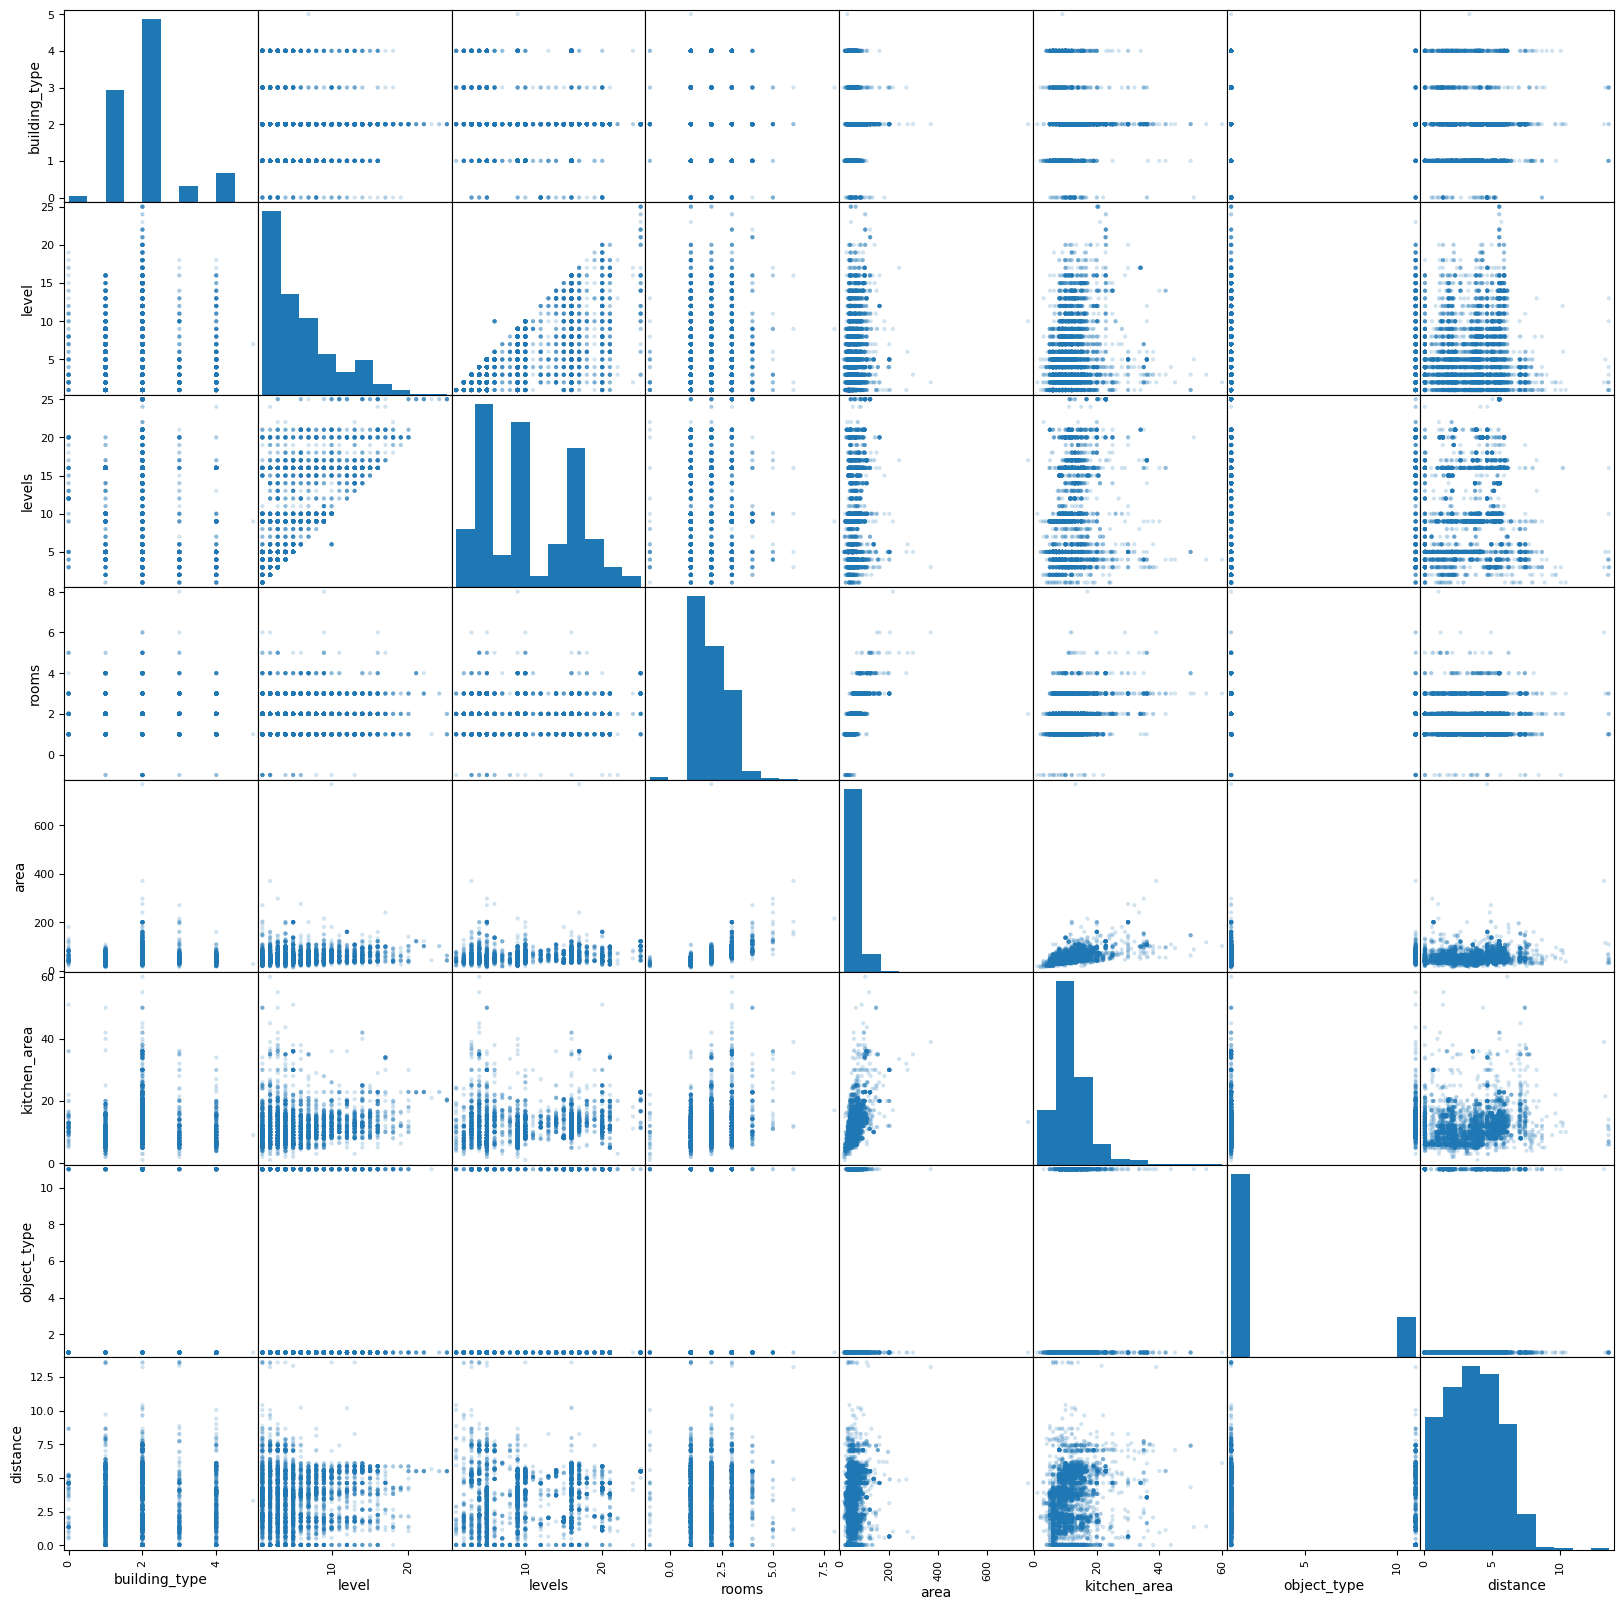

In [ ]:
pd.plotting.scatter_matrix(x, alpha=0.2, figsize=(20,20))

Чтобы была возможность оценить качество моделей, делим исходные данные на обучающие и тестовые.

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# 2. Линейные модели

In [ ]:
from sklearn import *

2.1. Простая линейная регрессия без оптимизации

Обучение

In [ ]:
d=df_nov[['area']]
k=df_nov[['price']]
d

,area
242,60.0
248,48.4
251,136.0
293,60.3
304,107.0
...,...
855278,20.8
855693,43.0
855715,40.0
856095,27.0


In [ ]:
model_LR = linear_model.LinearRegression()
model_LR.fit(d, k)

LinearRegression()

In [ ]:
yy_data_line= model_LR.predict(d)

In [ ]:
metrics.mean_squared_error(k,yy_data_line)

1174788601044.1597

Предсказание для тестовых данных

Оценка качества модели с помощью RMSE

In [ ]:
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



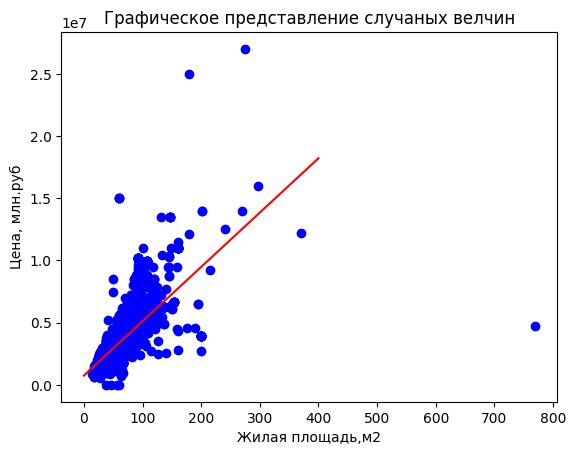

In [ ]:
xx = np.linspace(0, 400, num=2)
yy = model_LR.predict(xx.reshape(-1, 1))
plt.scatter(d,k, color='blue')
plt.xlabel('Жилая площадь,м2')
plt.ylabel('Цена, млн.руб')
plt.title("Графическое представление случаных велчин")
plt.plot(xx, yy, color='red')
plt.show()

# 2.2. Ridge

Linear least squares with l2 regularization. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html

In [ ]:
model_Ridge = linear_model.Ridge()
model_Ridge.fit(d,k)

Ridge()

In [ ]:
yy_data_ridge= model_Ridge.predict(d)

In [ ]:
yy_ridge= model_Ridge.predict(xx.reshape(-1, 1))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but Ridge was fitted with feature names



In [ ]:
metrics.mean_squared_error(k,yy_data_ridge)

1174788601044.2322

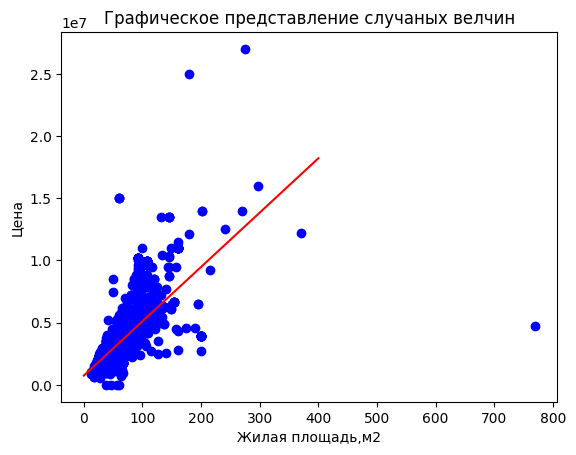

In [ ]:
plt.scatter(d, k, color='blue')
plt.xlabel('Жилая площадь,м2')
plt.ylabel('Цена')
plt.title("Графическое представление случаных велчин")
plt.plot(xx, yy, color='red')
plt.show()


# 2.3. Lasso.

In [ ]:
model_Lasso = linear_model.Lasso(alpha=0.1)
model_Lasso.fit(d, k)

Lasso(alpha=0.1)

In [ ]:
yy_Lasso = model_Lasso.predict(xx.reshape(-1, 1))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but Lasso was fitted with feature names



In [ ]:
yy_data_lasso= model_Ridge.predict(d)

In [ ]:
metrics.mean_squared_error(k, yy_data_lasso)

1174788601044.2322

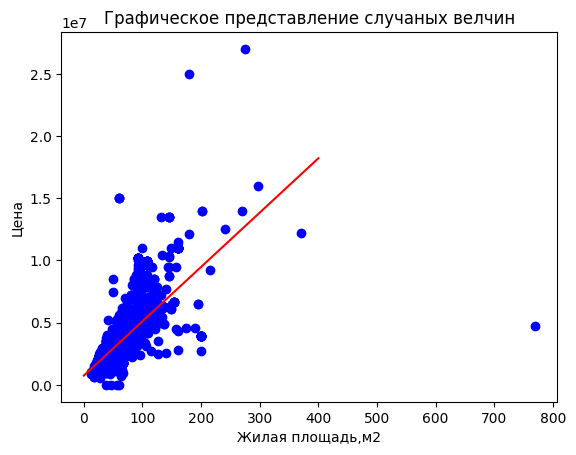

In [ ]:
plt.scatter(d, k, color='blue')
plt.xlabel('Жилая площадь,м2')
plt.ylabel('Цена')
plt.title("Графическое представление случаных велчин")
plt.plot(xx, yy, color='red')
plt.show()

# 2.4. Метод опорных векторов (SVM)

https://scikit-learn.ru/1-4-support-vector-machines/#regression

In [ ]:
model_SVM = svm.SVR(kernel='linear')

In [ ]:
model_SVM.fit(d, k)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



SVR(kernel='linear')

In [ ]:
yy_pred_SVM = model_SVM.predict(xx.reshape(-1, 1))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but SVR was fitted with feature names



In [ ]:
yy_data_SVM=model_SVM.predict(d)

In [ ]:
metrics.mean_squared_error(k, yy_data_SVM)

1241690517441.4805

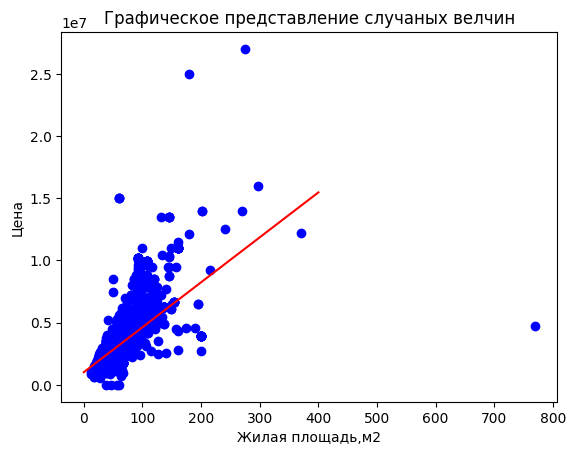

In [ ]:
xx = np.linspace(0, 400, num=2)
plt.scatter(d,k, color='blue')
plt.xlabel('Жилая площадь,м2')
plt.ylabel('Цена')
plt.title("Графическое представление случаных велчин")
plt.plot(xx, yy_pred_SVM, color='red')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



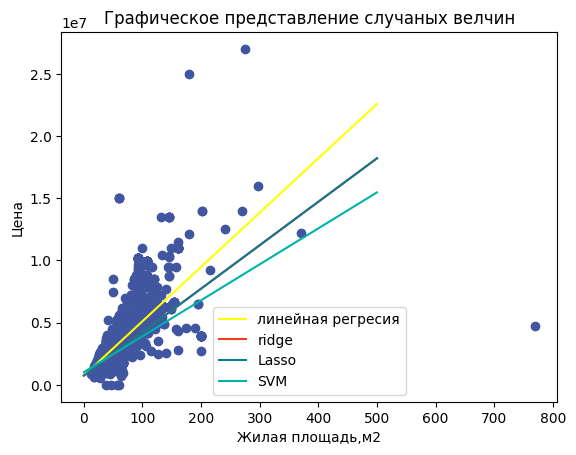

In [ ]:
xx = np.linspace(0, 500, num=2)
yy = model_LR.predict(xx.reshape(-1, 1))
plt.scatter(d, k, color='#4056a1')
plt.xlabel('Жилая площадь,м2')
plt.ylabel('Цена')
plt.title("Графическое представление случаных велчин")
plt.plot(xx, yy, color='#ffff00',label="линейная регресия")
plt.plot(xx, yy_ridge, color='#f13c20', label="ridge")
plt.plot(xx, yy_Lasso, color='#0c7b93', label="Lasso")
plt.plot(xx, yy_pred_SVM, color='#00b2a9', label="SVM")
plt.legend()
plt.show()

визуально подходит линейная регресия

из-за выбросов линии ушли ниже

# 3. К-ближайших соседей

Необходимо перебирать подаваемые значения,чтобы найти минимальную получаемую metrics


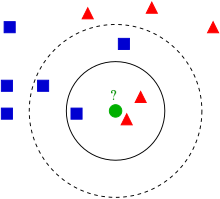

(https://upload.wikimedia.org/wikipedia/commons/e/e7/KnnClassification.svg)

Гиперпараметр - количество соседей

https://scikit-learn.ru/1-6-nearest-neighbors/#nearest-neighbors-regression

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
n_neighbors = 50
model_KN = KNeighborsRegressor(n_neighbors)

In [ ]:
model_KN.fit(x_train, y_train)

KNeighborsRegressor(n_neighbors=50)

In [ ]:
y_pred_KN = model_KN.predict(x_test)

In [ ]:
metrics.root_mean_squared_error(y_test, y_pred_KN)

1054580.9726530137

n_neighbors=8 RMSE = 986169.7106846181

n_neighbors=10 RMSE = 1000753.4656736007

n_neighbors=15 RMSE = 1048225.8006847325

n_neighbors=25 RMSE = 1055163.6445041837

n_neighbors=50 RMSE = 1054580.9726530137


Вывод: минимальное значение RMSE соответствует значению n_neighbors=8. Это самое оптимальное количество соседей,среди рассматреваемых

# 4. Деревья решений

Структура дерева представляет собой «листья» и «ветки». На рёбрах («ветках») дерева решения записаны признаки, от которых зависит целевая функция, в «листьях» записаны значения целевой функции, а в остальных узлах — признаки, по которым различаются случаи. Чтобы классифицировать новый случай, надо спуститься по дереву до листа и выдать соответствующее значение.

In [ ]:
model_tree = tree.DecisionTreeRegressor(max_depth=3)
model_tree.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=3)

In [ ]:
y_pred_tree = model_tree.predict(x_test)

In [ ]:
metrics.root_mean_squared_error(y_test, y_pred_tree)

1069196.5685807683

max_depth=10 RMSE = 881085.6470509592

max_depth=15 RMSE = 895488.2915305962

max_depth=25 RMSE = 867348.4458950525

max_depth=50 RMSE = 875108.3441540722

max_depth=75 RMSE = 893643.0379816517


Вывод: минимальное значение RMSE соответствует значению max_depth=25. Это самое оптимальное количество уровней дерева, среди рассматреваемых

In [ ]:
import matplotlib.pyplot as plt

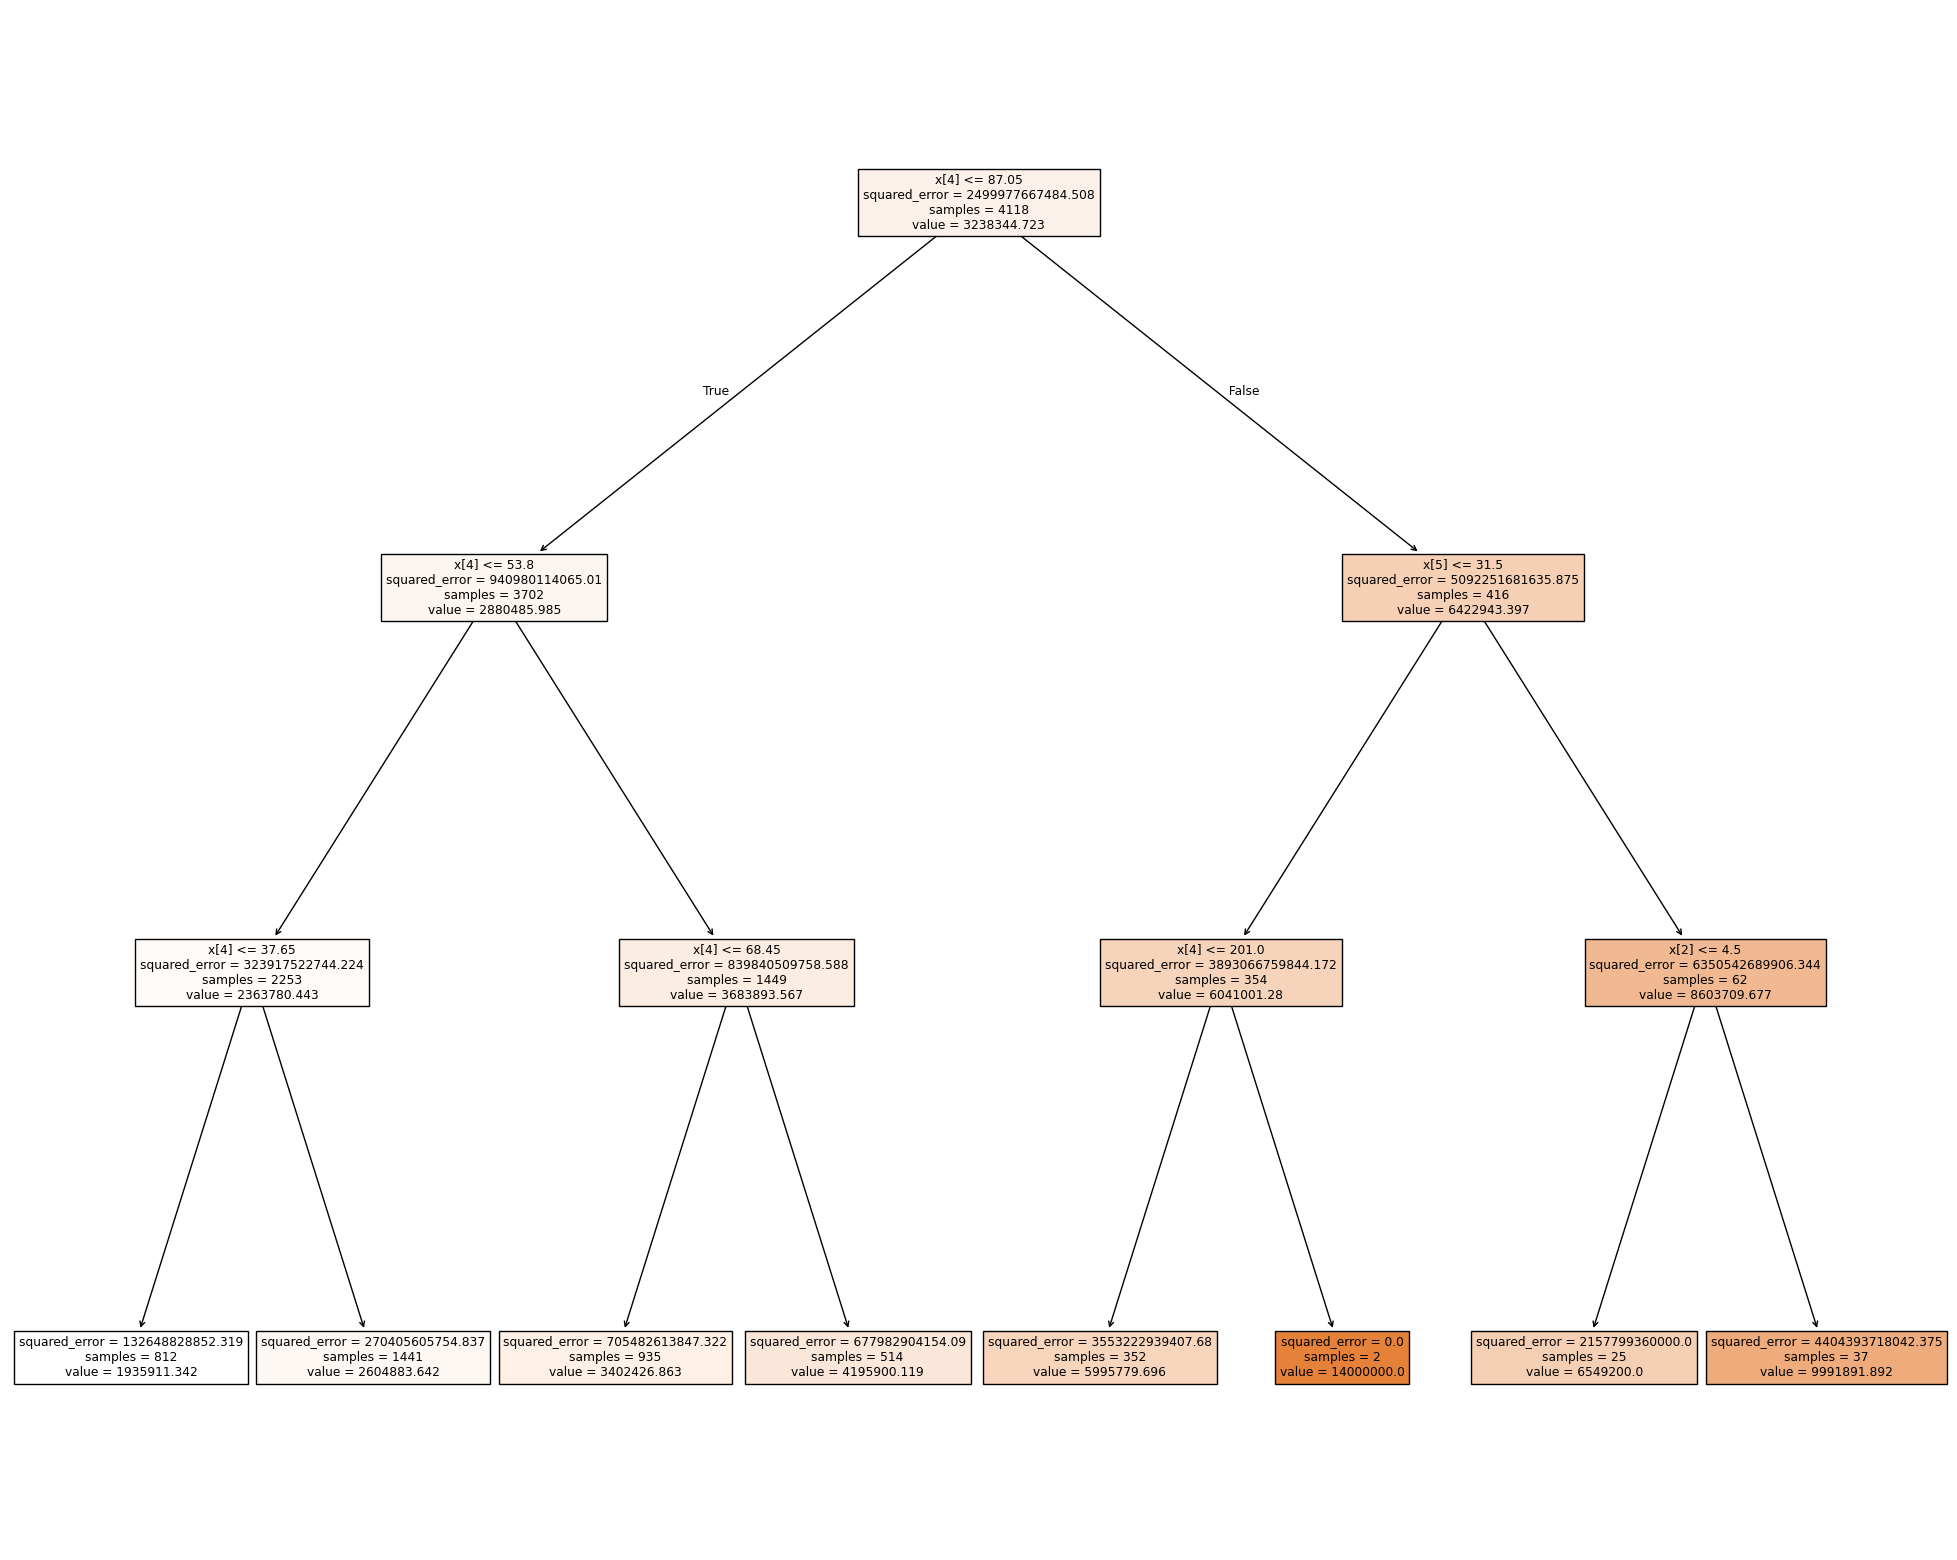

In [ ]:
_, ax = plt.subplots(figsize=(25,20))
tree.plot_tree(model_tree, filled=True, ax=ax)
plt.show()

# 5. Ансамбли (деревьев, других простых методов)

# 5.1. Лес случайных деревьев

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
model_rf = RandomForestRegressor(
    n_estimators=15,
    max_depth=50,
    random_state=3, bootstrap=True)
model_rf.fit(x_train,y_train)

RandomForestRegressor(max_depth=50, n_estimators=15, random_state=3)

In [ ]:
y_pred_rf = model_rf.predict(x_test)

In [ ]:
metrics.root_mean_squared_error(y_test, y_pred_rf)

813446.5551492088

n_estimators= 10 max_depth=3 random_state=3 получаем RMSE = 1072185.9922735738

n_estimators= 15 max_depth=3 random_state=3 получаем RMSE = 1061737.3215536864

n_estimators= 30 max_depth=3 random_state=3 получаем RMSE = 1051543.736062568

n_estimators=15 max_depth=10 random_state=3 получаем RMSE = 825143.036376165

n_estimators=15 max_depth=50 random_state=3 получаем RMSE = 813446.5551492088

Вывод: n_estimators=15 max_depth=50 являются наиболее эффективными значениями для функции, получаем значение 813446.5551492088, среди рассматреваемых

# 5.2. XGBoost

In [ ]:
import xgboost as xgb

In [ ]:
model_xgbr = xgb.XGBRegressor(verbosity=0,max_depth=40)
model_xgbr.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=40,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_xgbr = model_xgbr.predict(x_test)

In [ ]:
metrics.root_mean_squared_error(y_test, y_pred_xgbr)

861071.375

max_depth=15 RMSE = 866166.0625

max_depth=20 RMSE = 858603.375

max_depth=30 RMSE = 861085.5625

max_depth=40 RMSE = 861071.375

Вывод: для max_deph=20 функция принимает наименьшее значение RMSE = 858603.375,среди рассматреваемых

Методы автоматизации перебора гиперпараметров

# 6.1. Optuna

In [ ]:
!pip install optuna

In [ ]:
import optuna as optuna

In [ ]:
def objective(trial):
    params = {
        "random_state": trial.suggest_int("random_state", 1, 3),
        "n_estimators": trial.suggest_int("n_estimators", 1, 100),
        "max_depth": trial.suggest_int("max_depth", 1, 60),

    }
    model = RandomForestRegressor(**params, verbose=False)
    model.fit(x_train,y_train)
    predict = model.predict(x_test)
    return metrics.root_mean_squared_error(y_test, predict)

In [ ]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)

[I 2025-10-21 14:50:48,275] A new study created in memory with name: no-name-05980c52-941c-4218-ad67-1d92a8654053
[I 2025-10-21 14:50:48,763] Trial 0 finished with value: 1103229.3872012745 and parameters: {'random_state': 1, 'n_estimators': 84, 'max_depth': 2}. Best is trial 0 with value: 1103229.3872012745.
[I 2025-10-21 14:50:49,666] Trial 1 finished with value: 802725.7230319732 and parameters: {'random_state': 2, 'n_estimators': 30, 'max_depth': 58}. Best is trial 1 with value: 802725.7230319732.
[I 2025-10-21 14:50:49,795] Trial 2 finished with value: 960613.0434965822 and parameters: {'random_state': 1, 'n_estimators': 13, 'max_depth': 5}. Best is trial 1 with value: 802725.7230319732.
[I 2025-10-21 14:50:53,458] Trial 3 finished with value: 796085.0383093348 and parameters: {'random_state': 3, 'n_estimators': 65, 'max_depth': 37}. Best is trial 3 with value: 796085.0383093348.
[I 2025-10-21 14:50:55,097] Trial 4 finished with value: 785931.1557446129 and parameters: {'random_st

До optuna было 820497.6436759704, после 788597.4854478596 руб.. Стало лучше

In [ ]:
study.best_trial

FrozenTrial(number=4, state=1, values=[785931.1557446129], datetime_start=datetime.datetime(2025, 10, 21, 14, 50, 53, 459710), datetime_complete=datetime.datetime(2025, 10, 21, 14, 50, 55, 97287), params={'random_state': 3, 'n_estimators': 47, 'max_depth': 26}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'random_state': IntDistribution(high=3, log=False, low=1, step=1), 'n_estimators': IntDistribution(high=100, log=False, low=1, step=1), 'max_depth': IntDistribution(high=60, log=False, low=1, step=1)}, trial_id=4, value=None)

In [ ]:
study.best_params

{'random_state': 3, 'n_estimators': 47, 'max_depth': 26}

In [ ]:
fig = optuna.visualization.plot_optimization_history(study)
fig.show()

In [ ]:
fig = optuna.visualization.plot_param_importances(study)
fig.show()

In [ ]:
fig = optuna.visualization.plot_contour(study, params=["max_depth","n_estimators"])
fig.show()

большее колличество точек раставлено на темсной плоскости, т.к. значения лучше

# 8. Практическое использование



In [ ]:
a=model_rf.predict(pd.DataFrame([{
    'building_type':1,
    "level":10,
    "levels":10,
    "rooms":2,
    "area":53,
    "kitchen_area":8,
    "object_type":1,
    "distance":4.16,
    }]))
print("Цена квартиры:",round(a[0],2),'руб')

Цена квартиры: 3004600.0 руб


Стоимость квартиры с учетом инфляции примерно 5 мил руб

Ссылка на квартиру: https://www.avito.ru/novorossiysk/kvartiry/2-k._kvartira_53_m_1010_et._4356295062?context=H4sIAAAAAAAA_wE_AMD_YToyOntzOjEzOiJsb2NhbFByaW9yaXR5IjtiOjE7czoxOiJ4IjtzOjE2OiJZbTVPSHV6cVN1OEw0bHpCIjt9qI-ojD8AAAA

Цена не совпала(6 950 000руб),думаю проблема связана с тем, что данная модель не учитывает:

1.   Инфляцию
2.   Геополитические события
3.   Экономические кризисы



# Вывод

Удалось рассчитать стоимость квартиры на основе заданных параметров. Определили цену квартиры, учитывая ее характеристики, и именно модель случайного леса показала наилучшие результаты.